# Exploring Datasets for thesis


In [2]:
import pandas as pd
import re
import pycountry
import matplotlib.pyplot as plt

### UN Food and Agriculture Fisheries Tuna Catch Dataset (1918-2023)

Data from UN FAO (https://zenodo.org/records/17494424)
Metadata/explanation here: https://www.fao.org/fishery/geonetwork/srv/eng/catalog.search#/metadata/global_nominal_catch_firms_level0

Need:

- codes for:
  - Fishing Fleet
    - uses ISO 3166 country codes
  - Species
    - BET Bigeye Tuna
    - YFT Yellowfin Tuna
    - BFT Atlantic Bluefin Tuna
    - PBF Pacific Bluefin Tuna
    - SBF Southern Bluefin Tuna
  - Measurement Type
    - NC Nominal Catch
    - NL Nominal Landings
    - DL or DD is Discarded Alive or Dead
  - unit
    - t (metric tons)


In [ ]:
fao_all = pd.read_csv("datasets/global_nominal_catch_firms_level0_harmonized.csv")

#get year from the first four numbers in time_start
fao_all["year"] = fao_all["time_start"].str.extract(r"(\d{4})").astype(int)
fao_all.head()


In [ ]:
#graph PBF (Pacific Bluefin), Southern bluefin tuna (SBF), Atlantic bluefin tuna (BFT) catch over time
fao_3bluefin = fao_all[fao_all["species"].isin(["PBF", "SBF", "BFT"])]
#barplot of measurement_value by year and species
plt.figure(figsize=(10, 6))
for species in fao_3bluefin["species"].unique():
    species_data = fao_3bluefin[fao_3bluefin["species"] == species]
    plt.bar(species_data["year"], species_data["measurement_value"], label=species)
plt.xlabel("Year")
plt.ylabel("Catch (tonnes)")
plt.title("Catch of Pacific Bluefin, Southern Bluefin, and Atlantic Bluefin Tuna Over Time")
plt.legend()
plt.show()


all_tuna = fao_all[fao_all["species"].str.contains("BFT|PBF|SBF|YFT|BET", case=False, na=False)]
plt.figure(figsize=(12, 6))
for species in all_tuna["species"].unique():
    species_data = all_tuna[all_tuna["species"] == species].groupby("year")["measurement_value"].sum().reset_index()
    plt.bar(species_data["year"], species_data["measurement_value"], label=species)
plt.xlabel("Year")
plt.ylabel("Total Catch (measurement_value)")
plt.title("Total Catch of Tuna by Year and Species")
plt.legend()
plt.show()



In [ ]:
#atlantic bluefin tuna subset
atlantic_bluefin_tuna = fao_all[fao_all["species"].str.contains("BFT", case=False, na=False)]
atlantic_bluefin_tuna.head() #4000 rows

#column for year: take first four numbers in time_start column
atlantic_bluefin_tuna["year"] = atlantic_bluefin_tuna["time_start"].str.extract(r"(\d{4})").astype(int)
atlantic_bluefin_tuna.head()

#group by year, and for each source_authority, sum the catch
catch_by_year = atlantic_bluefin_tuna.groupby(["year", "source_authority"])["measurement_value"].sum().reset_index()
catch_by_year.head()


In [ ]:
#bar plot of measurement_value by year, with different colors for each source_authority
plt.figure(figsize=(12, 6))
for authority in catch_by_year["source_authority"].unique():
    authority_data = catch_by_year[catch_by_year["source_authority"] == authority]
    plt.bar(authority_data["year"], authority_data["measurement_value"], label=authority)
plt.xlabel("Year")
plt.ylabel("Total Catch (measurement_value)")
plt.title("Total Catch of Atlantic Bluefin Tuna by Year and Source Authority")
plt.legend()
plt.show()


In [ ]:
#subset for all tuna: BFT, YFT, PBF, SBF, BET
all_tuna = fao_all[fao_all["species"].str.contains("BFT|PBF|SBF|YFT|BET", case=False, na=False)]





#bar plot of measurement_value by year, with different colors for each species. Colors for BET should be red, YFT should be yellow
plt.figure(figsize=(12, 6))
for species in all_tuna["species"].unique():
    species_data = all_tuna[all_tuna["species"] == species].groupby("year")["measurement_value"].sum().reset_index()
    if species == "BET":
        plt.bar(species_data["year"], species_data["measurement_value"], label=species, color="red")
    elif species == "YFT":
        plt.bar(species_data["year"], species_data["measurement_value"], label=species, color="purple")
    elif species == "PBF":
        plt.bar(species_data["year"], species_data["measurement_value"], label=species, color="blue")
    elif species == "SBF":
        plt.bar(species_data["year"], species_data["measurement_value"], label=species, color="green")
    elif species == "BFT":
        plt.bar(species_data["year"], species_data["measurement_value"], label=species, color="orange")
plt.xlabel("Year")
plt.ylabel("Total Catch (measurement_value)")
plt.title("Total Catch of Tuna by Year and Species")
plt.legend()
plt.show()





#same plot but exclude YFT and BET
catch_by_year_bluefin = all_tuna[all_tuna["species"].isin(["BFT", "PBF", "SBF"])].groupby(["year", "species"])["measurement_value"].sum().reset_index()
plt.figure(figsize=(12, 6))
for species in catch_by_year_bluefin["species"].unique():
    species_data = catch_by_year_bluefin[catch_by_year_bluefin["species"] == species].groupby("year")["measurement_value"].sum().reset_index()
    plt.bar(species_data["year"], species_data["measurement_value"], label=species)
plt.xlabel("Year")
plt.ylabel("Total Catch (measurement_value)")
plt.title("Total Catch of Bluefin Tuna by Year and Species")
plt.legend()

In [ ]:
#names? 

unrecognized = fao_all[fao_all["fishing_fleet"].notna()]["fishing_fleet"].apply(
    lambda x: x if pycountry.countries.get(alpha_3=x) is None else None
).dropna().unique()
print(unrecognized)

In [ ]:
fao_all["country_name"] = fao_all["fishing_fleet"].apply(
    lambda x: country.name if pd.notnull(x) and (country := pycountry.countries.get(alpha_3=x)) else None
)

fao_all.head()

## NOAA Import/Export Dataset cleaning for prototype Sankey diagram

Downloaded from https://www.fisheries.noaa.gov/foss/f?p=215:2:14285563639484:::::
Import data from 1972 to 2026. Source file doesn't have all fish products, only ones that are relevant to sushi or Japanese food.

In [3]:
import_all = pd.read_csv("datasets/ANNUAL TRADE-NO AGGREGATION_.csv")
first_row = import_all.iloc[0]
#rename columns using first row
import_all.columns = first_row
import_all = import_all[1:] #drop first row


#year, Value USD and Volume kg should be int or float, not string.
import_all["Year"] = import_all["Year"].astype(int)
# value and volume have commas, so remove commas and convert to int
import_all["Value (USD)"] = import_all["Value (USD)"].str.replace(",", "").astype(int)
import_all["Volume (kg)"] = import_all["Volume (kg)"].str.replace(",", "").astype(int)


import_all.head()

/var/folders/s6/l4_0rpsd3xs3vxs6x047x7t80000gn/T/ipykernel_77512/486318079.py:1: DtypeWarning: Columns (0,6,7,8,9) have mixed types. Specify dtype option on import or set low_memory=False.
  import_all = pd.read_csv("datasets/ANNUAL TRADE-NO AGGREGATION_.csv")


,Year,Continent,Country Name,Product Name,Edible code,US Customs District,Census Country Code,Census District Code,FAO Country Code,HTS Number,Value (USD),Volume (kg),Calculated Duty (USD)
1,2026,NORTH AMERICA,CANADA,SALMON CHINOOK FRESH FARMED,E,"BUFFALO, NY",1220,09,124,0302130013,29021,1836,0
2,2026,NORTH AMERICA,CANADA,SALMON CHINOOK FRESH FARMED,E,"SEATTLE, WA",1220,30,124,0302130013,2145067,112804,0
3,2026,OCEANIA,NEW ZEALAND,SALMON CHINOOK FRESH FARMED,E,"NEW YORK, NY",6141,10,554,0302130013,592978,36853,"88,946"
4,2026,OCEANIA,NEW ZEALAND,SALMON CHINOOK FRESH FARMED,E,"LOS ANGELES, CA",6141,27,554,0302130013,1963164,128328,"294,477"
5,2026,OCEANIA,NEW ZEALAND,SALMON CHINOOK FRESH FARMED,E,"SAN FRANCISCO, CA",6141,28,554,0302130013,115265,7184,"17,289"


In [4]:
#looking at Salmon (Wild) and Salmon (Farmed) NOT CONTAINING "Meat"
salmon_sushi = import_all[import_all["Product Name"].str.contains("Salmon", case=False, na=False)]
#filter cases where "Product Name" contains "Meat" or "Canned" or 
salmon_sushi = salmon_sushi[~salmon_sushi["Product Name"].str.contains("Steaks|Fillet|Meat|Canned|Frozen|Roe|Smoked|Salted|NSPF", case=False, na=False)]
salmon_sushi.head()
salmon_sushi["Product Name"].unique()


array(['SALMON CHINOOK FRESH FARMED', 'SALMON CHINOOK FRESH WILD',
       'SALMON COHO FRESH WILD', 'SALMON ATLANTIC FRESH FARMED',
       'SALMON ATLANTIC FRESH WILD', 'SALMON ATLANTIC,DANUBE FRESH',
       'SALMON CHUM FRESH', 'SALMON PINK FRESH', 'SALMON SOCKEYE FRESH',
       'SALMON COHO FRESH FARMED', 'SALMON ATLANTIC FRESH',
       'SALMON CHINOOK FRESH', 'SALMON COHO FRESH'], dtype=object)

In [5]:
#Look at only Bluefin Tuna, and simplify dataframe for export and use in Sankey diagram



import_tuna = import_all[import_all["Product Name"].str.contains("TUNA", case=False, na=False)]
#drop columns that aren't used
import_tuna = import_tuna[["Year","Continent", "Country Name", "Product Name", "US Customs District", "Value (USD)", "Volume (kg)"]]

#subset for only bluefin tuna
import_bluefin_tuna = import_tuna[import_tuna["Product Name"].str.contains("BLUEFIN", case=False, na=False)]

import_bluefin_tuna.head()


,Year,Continent,Country Name,Product Name,US Customs District,Value (USD),Volume (kg)
207,2026,ASIA,JAPAN,"TUNA BLUEFIN ATLANTIC,PACIFIC FRESH","NEW YORK, NY",35213,1272
208,2026,ASIA,JAPAN,"TUNA BLUEFIN ATLANTIC,PACIFIC FRESH","LOS ANGELES, CA",86467,3094
209,2026,ASIA,JAPAN,"TUNA BLUEFIN ATLANTIC,PACIFIC FRESH","HONOLULU, HI",39025,712
210,2026,ASIA,JAPAN,"TUNA BLUEFIN ATLANTIC,PACIFIC FRESH","MIAMI, FL",34912,741
211,2026,ASIA,JAPAN,"TUNA BLUEFIN ATLANTIC,PACIFIC FRESH","HOUSTON-GALVESTON, TX",35669,1073


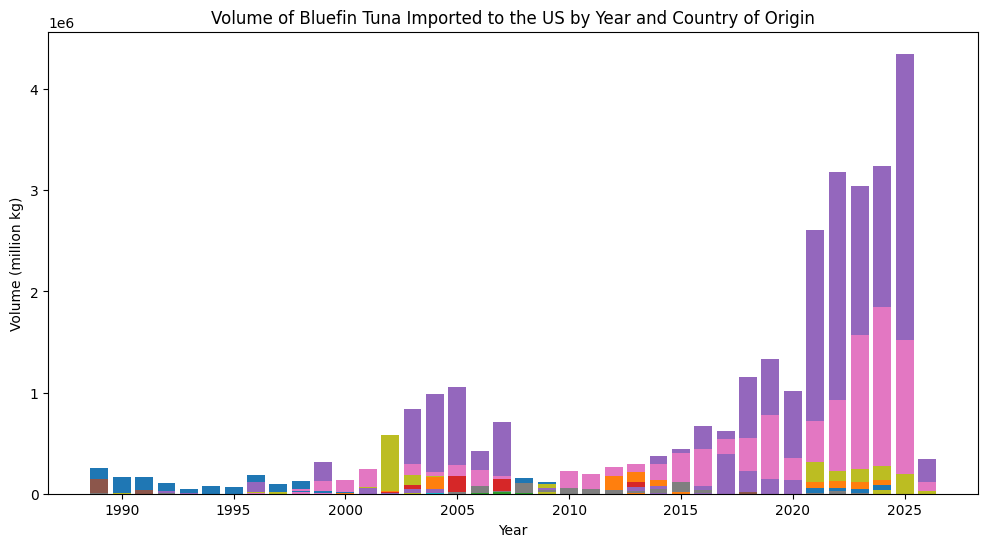

In [6]:
# how much tuna is imported to the us per year by country of origin?
    #add up each customs district, and then group by year and country of origin
import_bluefin_tuna_grouped = import_bluefin_tuna.groupby(["Year", "Country Name"])["Volume (kg)"].sum().reset_index()
import_bluefin_tuna_grouped.head()
#graph volume for all years, color code by country of origin
plt.figure(figsize=(12, 6))
for country in import_bluefin_tuna_grouped["Country Name"].unique():    
    country_data = import_bluefin_tuna_grouped[import_bluefin_tuna_grouped["Country Name"] == country]
    plt.bar(country_data["Year"], country_data["Volume (kg)"], label=country)
plt.xlabel("Year")
plt.ylabel("Volume (million kg)")
plt.title("Volume of Bluefin Tuna Imported to the US by Year and Country of Origin")
# plt.legend()
plt.show()


In [ ]:
#export to csv for use in sankey diagram
# import_bluefin_tuna.to_csv("datasets/bluefin_tuna_imports.csv", index=False)

In [ ]:
#tuna and salmon dataset

fish_for_sushi = import_all[import_all["Product Name"].str.contains("TUNA|SALMON", case=False, na=False)]

#remove Product Names that contain "Steaks|Fillet|Meat|Canned|Frozen|Roe|Smoked|Salted|NSPF"
fish_for_sushi = fish_for_sushi[~fish_for_sushi["Product Name"].str.contains("Steaks|Fillet|Meat|Canned|Frozen|Roe|Smoked|Salted|NSPF", case=False, na=False)]
#removing non Bluefin, Yellowfin, Bigeye tuna
fish_for_sushi = fish_for_sushi[~fish_for_sushi["Product Name"].str.contains("Albacore|Skipjack", case=False, na=False)]
fish_for_sushi["Product Name"].unique()

#If Product Name contains "SALMON" and "FARMED", change to "Salmon (Farmed)". If Product Name contains "SALMON" and "WILD", change to "Salmon (Wild)". If not, keep as is.
def simplify_product_name(name):
    if "SALMON" in name.upper() and "FARMED" in name.upper():
        return "SALMON FARMED"
    elif "SALMON" in name.upper() and "WILD" in name.upper():
        return "SALMON WILD"
    #else if Salmon has no Farmed or Wild, change to just Salmon (UNSPECIFIED)
    elif "SALMON" in name.upper():
        return "SALMON UNSPECIFIED"
    #else if Tuna is TUNA BLUEFIN ATLANTIC,PACIFIC FRESH rename to TUNA BLUEFIN FRESH
    elif "TUNA" in name.upper() and "BLUEFIN" in name.upper() and "FRESH" in name.upper():
        return "TUNA BLUEFIN FRESH"
    else:
        return name



fish_for_sushi["Product Name"] = fish_for_sushi["Product Name"].apply(simplify_product_name)
fish_for_sushi["Product Name"].unique()



In [ ]:
#export to CSV
# fish_for_sushi.to_csv("datasets/fish_for_sushi.csv", index=False)

## Looking at NYC Restaurants - can I find sushi specifically?


In [ ]:
nyc_rest = pd.read_csv("datasets/nyc_rest_2026.csv")
nyc_rest.head()

In [ ]:
#cuisine descriptions
nyc_rest["CUISINE DESCRIPTION"].unique() #Japanese is included but no sushi specific category

# GIS

## Tuna Catch 1° Latitude
Global monthly catches from tuna surface fisheries by 1° grid (1958-2023) (FIRMS level 0)
https://zenodo.org/records/17705519

Codes for CWP: 
https://www.fao.org/fishery/geonetwork/srv/eng/catalog.search#/metadata/cwp-grid-map-5deg_x_5deg

In [ ]:
tuna_map_5deg_harmonized = pd.read_csv("datasets/tuna_map/global_catch_5deg_1m_firms_level0_harmonized.csv")
tuna_map_5deg_pub = pd.read_csv("datasets/tuna_map/global_catch_5deg_1m_firms_level0_public.csv")

In [ ]:
tuna_map_5deg_harmonized.head()
tuna_map_5deg_pub.head()

In [ ]:
print(len(tuna_map_5deg_harmonized))
print(len(tuna_map_5deg_pub))

In [ ]:
species_of_interest = ["BFT","PBF","SBF","YFT","BET"]
tuna_map_5deg_pub_subset = tuna_map_5deg_pub[tuna_map_5deg_pub["species"].isin(species_of_interest)]
tuna_map_5deg_pub_subset_2023 = tuna_map_5deg_pub_subset[tuna_map_5deg_pub_subset["year"] == 2023]
tuna_map_5deg_pub_subset_2023.head()

geographic identifiers collected from cwp-grid-map-5deg_x_5deg.csv

In [ ]:
geo_identifiers = pd.read_csv("datasets/tuna_map/cwp-grid-map-5deg_x_5deg.csv")
geo_identifiers.head()